**CELL 1 — IMPORTING LIBRARIES**

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**CELL 2 — LOAD DATASET**

In [10]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train.csv")

print("Dataset Loaded Successfully")

print(df.head())

Dataset Loaded Successfully
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region 

**CELL 3 — DATASET INFORMATION**

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

**CELL 4 — DATA CLEANING & PREPROCESSING**

In [12]:
# Convert Date Column into Datetime Format

df['Order Date'] = pd.to_datetime(df['Order Date'],
                                  dayfirst=True)

# Check Missing Values

print(df.isnull().sum())

# Remove Duplicate Rows

print("Duplicate Rows Before Removal :",
      df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After Removal :",
      df.duplicated().sum())

# Sort Dataset by Date

df = df.sort_values(by='Order Date')

print("Cleaned Data Shape :", df.shape)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicate Rows Before Removal : 0
Duplicate Rows After Removal : 0
Cleaned Data Shape : (9800, 18)


**CELL 5 — CREATE DATE FEATURES**

In [13]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Day_Name'] = df['Order Date'].dt.day_name()
print(df.head())

      Row ID        Order ID Order Date   Ship Date       Ship Mode  \
7980    7981  CA-2015-103800 2015-01-03  07/01/2015  Standard Class   
741      742  CA-2015-112326 2015-01-04  08/01/2015  Standard Class   
740      741  CA-2015-112326 2015-01-04  08/01/2015  Standard Class   
739      740  CA-2015-112326 2015-01-04  08/01/2015  Standard Class   
1759    1760  CA-2015-141817 2015-01-05  12/01/2015  Standard Class   

     Customer ID  Customer Name      Segment        Country          City  \
7980    DP-13000  Darren Powers     Consumer  United States       Houston   
741     PO-19195  Phillina Ober  Home Office  United States    Naperville   
740     PO-19195  Phillina Ober  Home Office  United States    Naperville   
739     PO-19195  Phillina Ober  Home Office  United States    Naperville   
1759    MB-18085     Mick Brown     Consumer  United States  Philadelphia   

      ...   Region       Product ID         Category Sub-Category  \
7980  ...  Central  OFF-PA-10000174  Offi

**CELL 6 — DESCRIPTIVE STATISTICS**

In [14]:
print("Total Sales :", df['Sales'].sum())
print("Average Sales :", df['Sales'].mean())
print("Maximum Sales :", df['Sales'].max())
print("Minimum Sales :", df['Sales'].min())
print(df.describe())

Total Sales : 2261536.7827000003
Average Sales : 230.7690594591837
Maximum Sales : 22638.48
Minimum Sales : 0.444
            Row ID                     Order Date   Postal Code         Sales  \
count  9800.000000                           9800   9789.000000   9800.000000   
mean   4900.500000  2017-05-01 05:13:51.673469440  55273.322403    230.769059   
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000   
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000   
50%    4900.500000            2017-06-26 00:00:00  58103.000000     54.490000   
75%    7350.250000            2018-05-15 00:00:00  90008.000000    210.605000   
max    9800.000000            2018-12-30 00:00:00  99301.000000  22638.480000   
std    2829.160653                            NaN  32041.223413    626.651875   

              Year        Month          Day  
count  9800.000000  9800.000000  9800.000000  
mean   2016.724184     7.818469    15.486837  
min    2015.000

**CELL 7 — DAILY SALES TREND ANALYSIS**

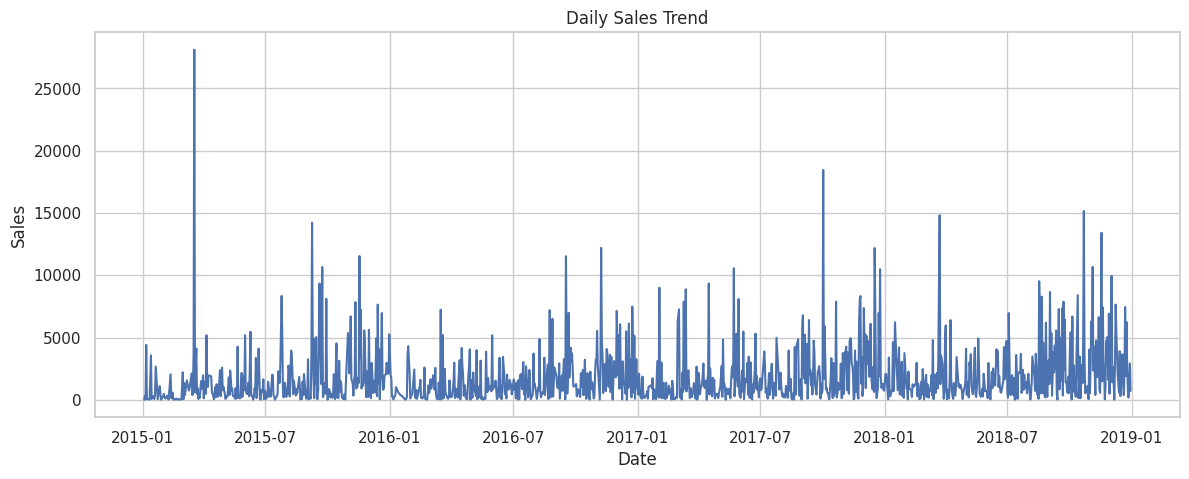

In [15]:
daily_sales = df.groupby('Order Date')['Sales'].sum()
plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**CELL 8 — MONTHLY SALES ANALYSIS**

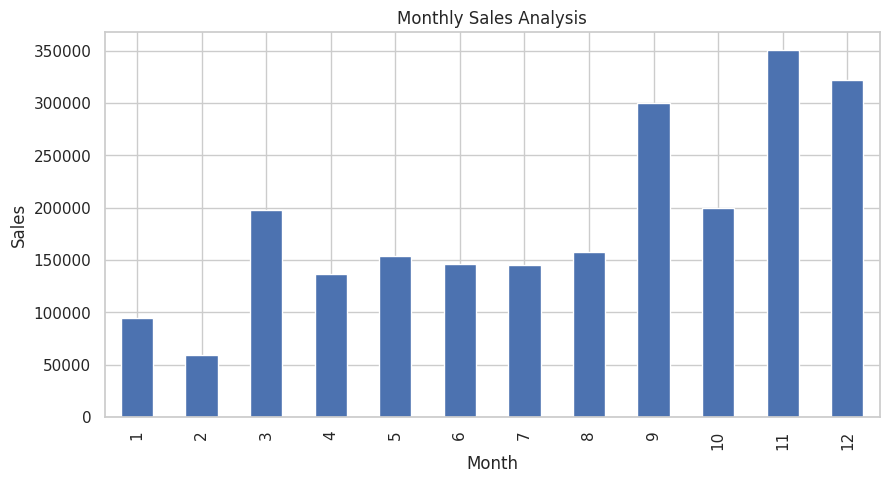

In [16]:
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**CELL 9 — YEARLY SALES ANALYSIS**

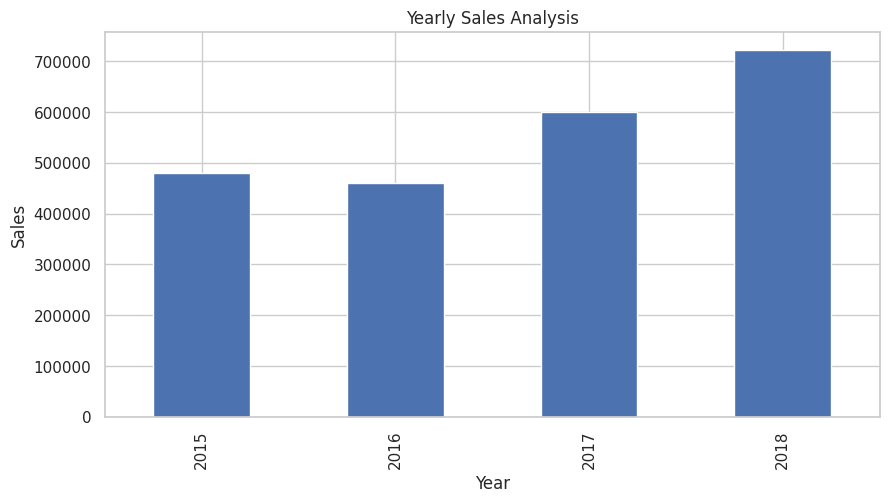

In [17]:
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.figure(figsize=(10,5))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Analysis")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

**CELL 10 — DAY WISE SALES ANALYSIS**

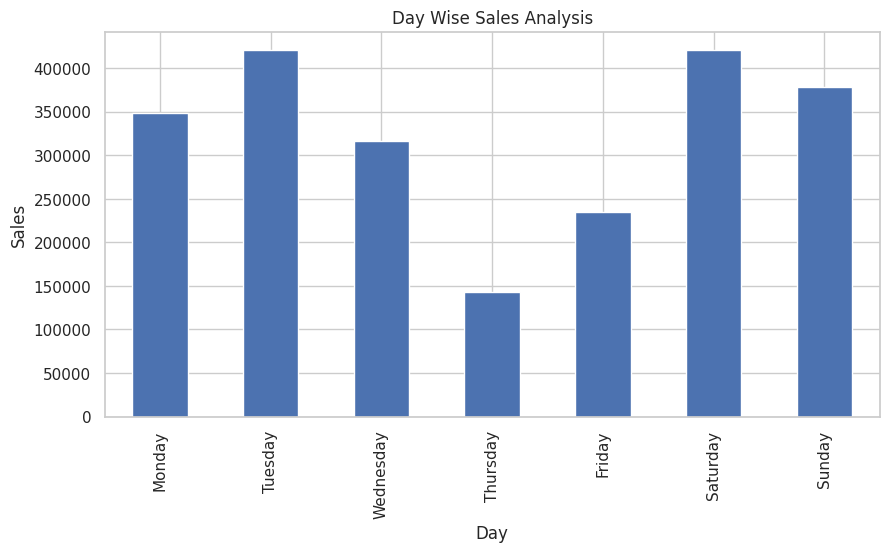

In [18]:
day_sales = df.groupby('Day_Name')['Sales'].sum()
order = ['Monday',
         'Tuesday',
         'Wednesday',
         'Thursday',
         'Friday',
         'Saturday',
         'Sunday']
day_sales = day_sales.reindex(order)
plt.figure(figsize=(10,5))
day_sales.plot(kind='bar')
plt.title("Day Wise Sales Analysis")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

**CELL 11 — CATEGORY WISE SALES ANALYSIS**

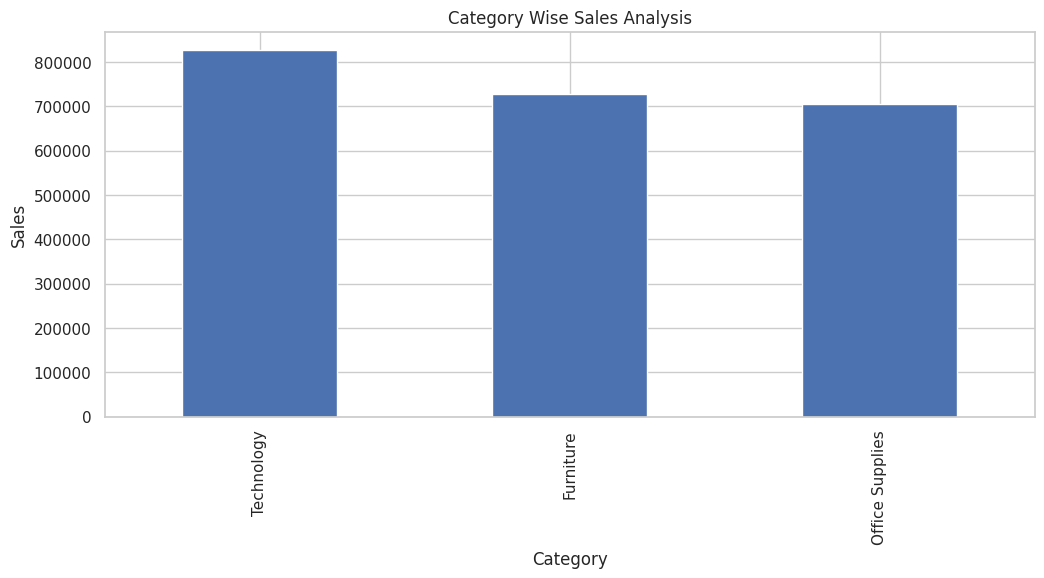

In [19]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales = category_sales.sort_values(ascending=False)
plt.figure(figsize=(12,5))
category_sales.plot(kind='bar')
plt.title("Category Wise Sales Analysis")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

**CELL 12 — PRODUCT WISE SALES ANALYSIS**

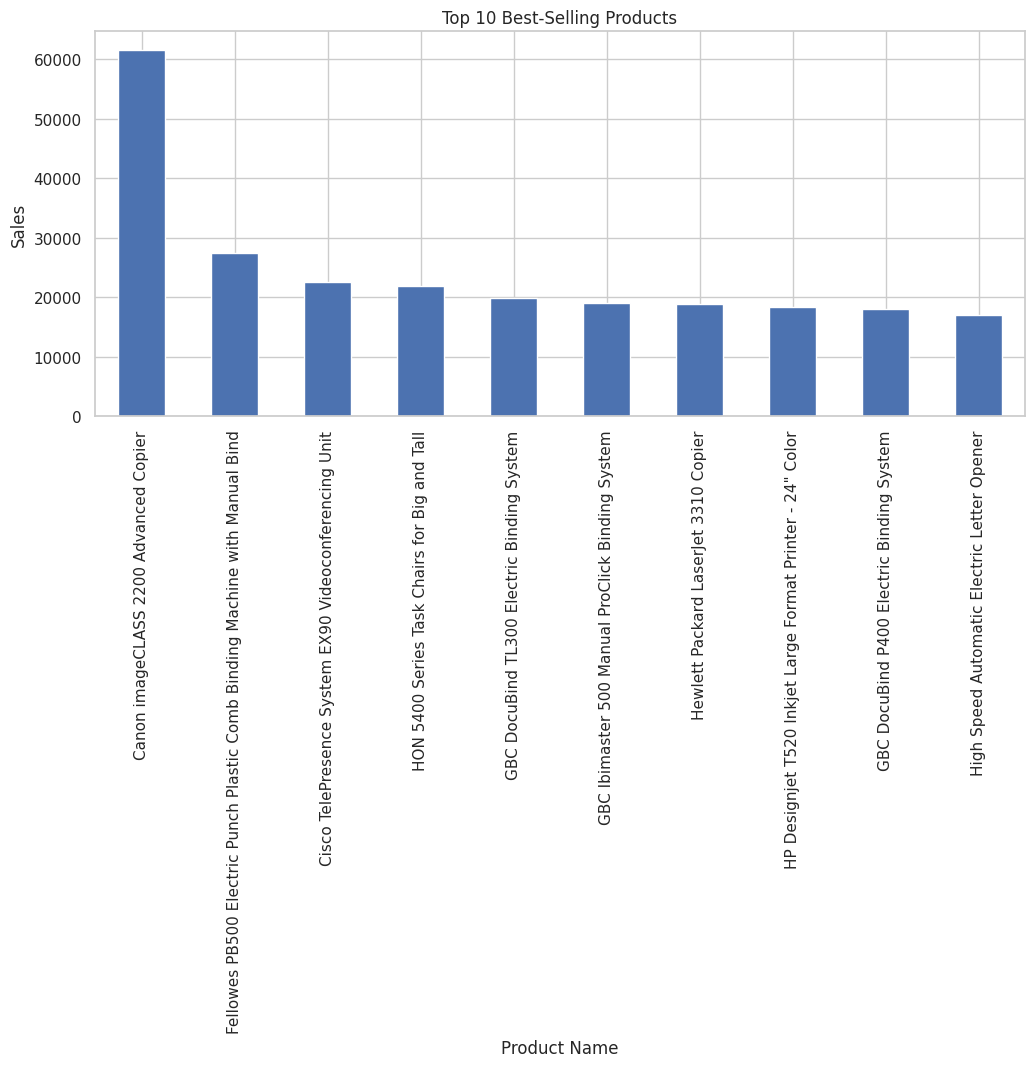

In [20]:
item_sales = df.groupby('Product Name')['Sales'].sum()
item_sales = item_sales.sort_values(ascending=False)
top_items = item_sales.head(10)
plt.figure(figsize=(12,5))
top_items.plot(kind='bar')
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.show()

**CELL 13 — LOW PERFORMING PRODUCTS**

In [21]:
low_items = item_sales.tail(10)
print("Low Performing Products")
print(low_items)

Low Performing Products
Product Name
Stockwell Gold Paper Clips                                          8.096
4009 Highlighters                                                   8.040
Xerox 1989                                                          7.968
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Acme Serrated Blade Letter Opener                                   7.632
Grip Seal Envelopes                                                 7.072
Xerox 20                                                            6.480
Avery 5                                                             5.760
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Name: Sales, dtype: float64


**CELL 14 — SALES DISTRIBUTION**

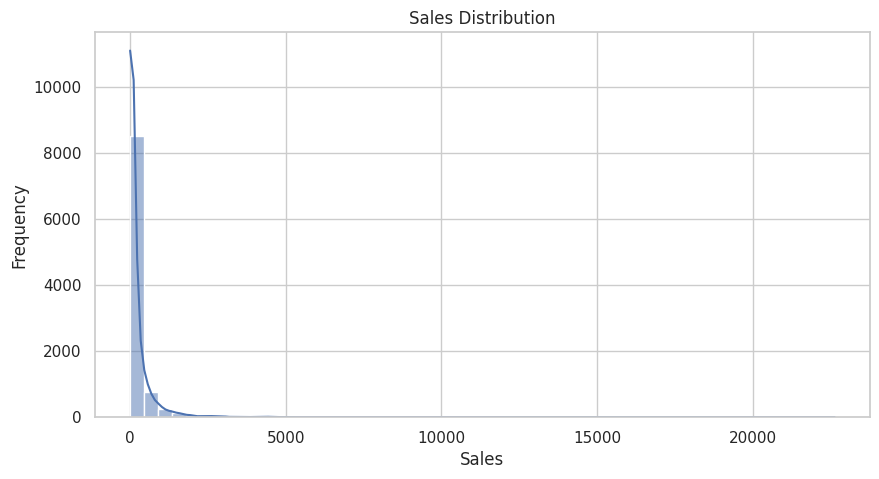

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'],
             bins=50,
             kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

**CELL 15 — OUTLIER DETECTION**

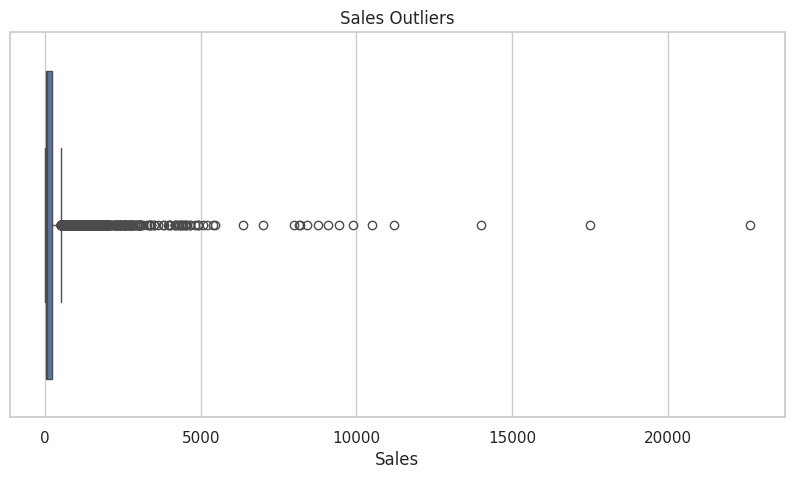

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

**CELL 16 — RELATIONSHIP ANALYSIS**

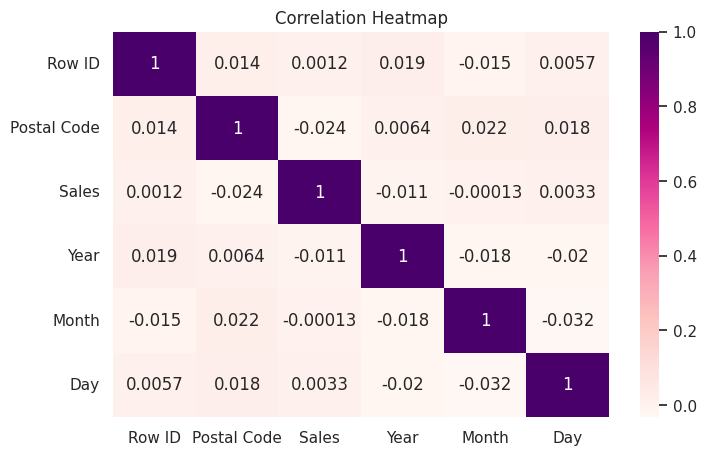

In [26]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='RdPu')
plt.title("Correlation Heatmap")
plt.show()

**CELL 17 — SIMPLE SALES FORECASTING**

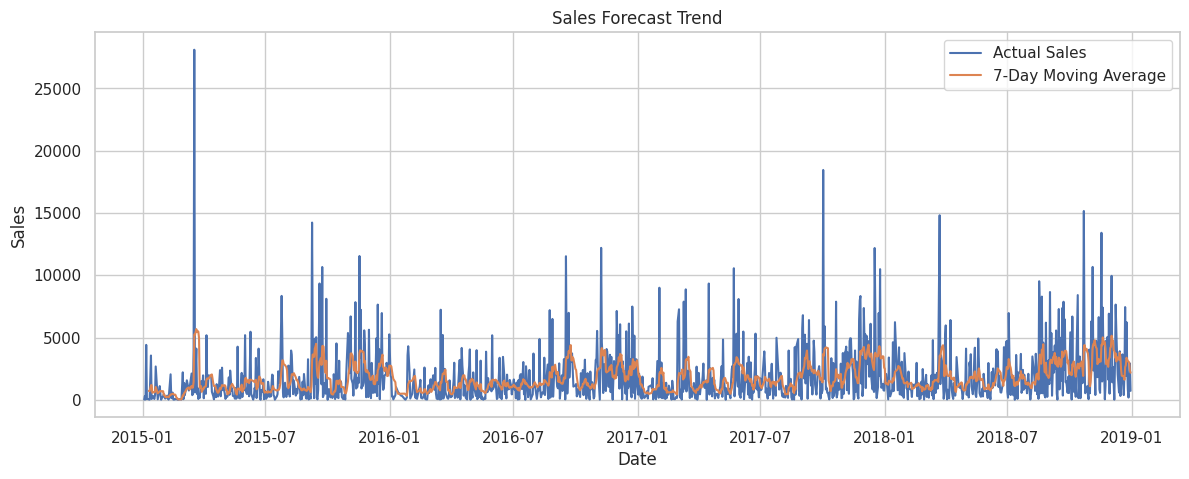

In [27]:
daily_sales_ma = daily_sales.rolling(window=7).mean()
plt.figure(figsize=(14,5))
plt.plot(daily_sales,
         label='Actual Sales')
plt.plot(daily_sales_ma,
         label='7-Day Moving Average')
plt.legend()
plt.title("Sales Forecast Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**CELL 18 — BUSINESS INSIGHTS**

In [28]:
print("Top Performing Category :",
      category_sales.idxmax())
print("Best Selling Product :",
      item_sales.idxmax())
print("Peak Sales Month :",
      monthly_sales.idxmax())
print("Lowest Sales Month :",
      monthly_sales.idxmin())

Top Performing Category : Technology
Best Selling Product : Canon imageCLASS 2200 Advanced Copier
Peak Sales Month : 11
Lowest Sales Month : 2


**CELL 19 — PROJECT CONCLUSION**

In [29]:
print("""
PROJECT CONCLUSION

1. Historical sales data was analyzed successfully
   using Exploratory Data Analysis (EDA).

2. Monthly, yearly, and daily sales trends were identified.

3. Seasonal sales behavior and peak sales periods
   were detected.

4. High-performing product categories and best-selling
   products were identified.

5. Low-performing products were analyzed to support
   business improvement decisions.

6. Correlation analysis helped understand relationships
   between sales-related variables.

7. Data visualization techniques improved understanding
   of sales distribution and trends.

8. Moving Average forecasting helped estimate future
   sales patterns.

9. The project supports:
   • Inventory Management
   • Sales Planning
   • Marketing Strategies
   • Business Decision-Making
""")


PROJECT CONCLUSION

1. Historical sales data was analyzed successfully
   using Exploratory Data Analysis (EDA).

2. Monthly, yearly, and daily sales trends were identified.

3. Seasonal sales behavior and peak sales periods
   were detected.

4. High-performing product categories and best-selling
   products were identified.

5. Low-performing products were analyzed to support
   business improvement decisions.

6. Correlation analysis helped understand relationships
   between sales-related variables.

7. Data visualization techniques improved understanding
   of sales distribution and trends.

8. Moving Average forecasting helped estimate future
   sales patterns.

9. The project supports:
   • Inventory Management
   • Sales Planning
   • Marketing Strategies
   • Business Decision-Making

